In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats

In [3]:
data = pd.read_csv(
    "fbref_task2_eligible_fw_mf.csv"
)

display(data.head())

print("Dataset shape:", data.shape)
print("\nPosition counts:")
print(data["Primary_Position"].value_counts())

,Rk,Player,Pos,Primary_Position,Squad,Age,90s,Gls,Sh,SoT,SoT%,Sh/90,SoT/90
0,19,Tyler Adams,MF,MF,us USA,27,3.8,0,0,0,NaN,0.00,0.00
1,25,Akram Afif,FWMF,FW,qa Qatar,29,2.6,0,2,0,0.0,0.76,0.00
2,28,Ali Ahmed,MF,MF,ca Canada,25,2.6,0,2,1,50.0,0.77,0.38
3,39,Kerim Alajbegović,MF,MF,ba Bosnia–Herz,18,3.1,1,4,1,25.0,1.30,0.32
4,49,Thiago Almada,MF,MF,ar Argentina,25,2.7,0,5,2,40.0,1.87,0.75


Dataset shape: (291, 13)

Position counts:
Primary_Position
MF    217
FW     74
Name: count, dtype: int64


In [4]:
print("Data types:")
print(data.dtypes)

print("\nMissing values:")
print(data.isnull().sum())

print("\nDuplicate rows:")
print(data.duplicated().sum())

print("\nPosition counts:")
print(data["Primary_Position"].value_counts())

Data types:
Rk                    int64
Player               object
Pos                  object
Primary_Position     object
Squad                object
Age                   int64
90s                 float64
Gls                   int64
Sh                    int64
SoT                   int64
SoT%                float64
Sh/90               float64
SoT/90              float64
dtype: object

Missing values:
Rk                   0
Player               0
Pos                  0
Primary_Position     0
Squad                0
Age                  0
90s                  0
Gls                  0
Sh                   0
SoT                  0
SoT%                16
Sh/90                0
SoT/90               0
dtype: int64

Duplicate rows:
0

Position counts:
Primary_Position
MF    217
FW     74
Name: count, dtype: int64


In [5]:
forwards_population = data[
    data["Primary_Position"] == "FW"
].copy()

midfielders_population = data[
    data["Primary_Position"] == "MF"
].copy()

print(
    "Eligible forwards:",
    len(forwards_population)
)

print(
    "Eligible midfielders:",
    len(midfielders_population)
)

Eligible forwards: 74
Eligible midfielders: 217


In [6]:
forwards_sample = forwards_population.sample(
    n=50,
    random_state=42
)

midfielders_sample = midfielders_population.sample(
    n=50,
    random_state=42
)

sample = pd.concat(
    [
        forwards_sample,
        midfielders_sample
    ],
    ignore_index=True
)

print(
    sample["Primary_Position"].value_counts()
)

Primary_Position
FW    50
MF    50
Name: count, dtype: int64


In [7]:
display(
    sample[
        [
            "Player",
            "Squad",
            "Pos",
            "Primary_Position",
            "90s",
            "SoT/90"
        ]
    ]
)

,Player,Squad,Pos,Primary_Position,90s,SoT/90
0,Jordan Ayew,gh Ghana,FW,FW,3.3,0.00
1,Crysencio Summerville,nl Netherlands,FW,FW,2.8,0.71
2,Breel Embolo,ch Switzerland,FW,FW,5.6,0.90
3,Akram Afif,qa Qatar,FWMF,FW,2.6,0.00
4,Alexander Isak,se Sweden,FW,FW,4.0,1.51
...,...,...,...,...,...,...
95,Danley Jean-Jacques,ht Haiti,MF,MF,2.9,0.00
96,Jamal Musiala,de Germany,MF,MF,3.0,0.33
97,John Yeboah,ec Ecuador,MF,MF,3.5,0.87
98,Bruno Guimarães,br Brazil,MF,MF,4.6,0.43


In [8]:
descriptive_stats = (
    sample
    .groupby(
        "Primary_Position"
    )["SoT/90"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        standard_deviation="std",
        minimum="min",
        maximum="max"
    )
)

display(
    descriptive_stats.round(2)
)

,count,mean,median,standard_deviation,minimum,maximum
Primary_Position,,,,,,
FW,50,0.91,0.86,0.69,0.0,2.98
MF,50,0.46,0.36,0.50,0.0,2.02


In [9]:
forward_sot90 = (
    forwards_sample[
        "SoT/90"
    ]
)

midfielder_sot90 = (
    midfielders_sample[
        "SoT/90"
    ]
)

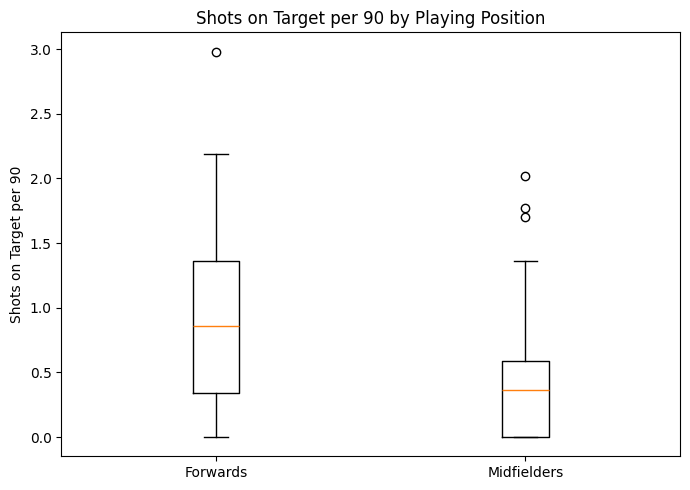

In [10]:
plt.figure(
    figsize=(7, 5)
)

plt.boxplot(
    [
        forward_sot90,
        midfielder_sot90
    ],
    tick_labels=[
        "Forwards",
        "Midfielders"
    ]
)

plt.title(
    "Shots on Target per 90 by Playing Position"
)

plt.ylabel(
    "Shots on Target per 90"
)

plt.tight_layout()
plt.show()

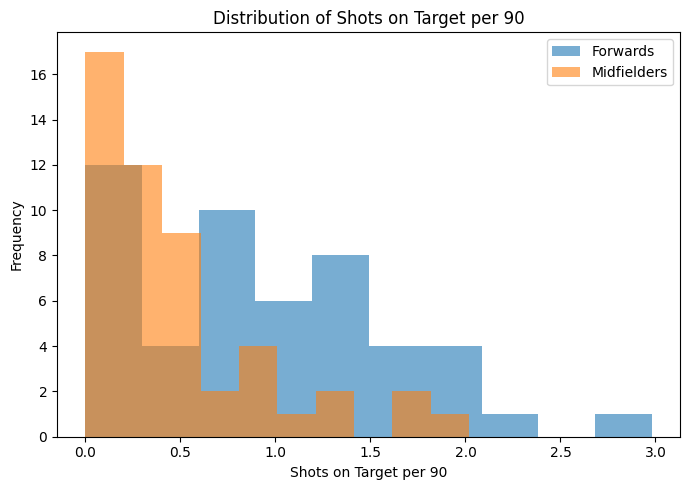

In [11]:
plt.figure(
    figsize=(7, 5)
)

plt.hist(
    forward_sot90,
    alpha=0.6,
    label="Forwards"
)

plt.hist(
    midfielder_sot90,
    alpha=0.6,
    label="Midfielders"
)

plt.xlabel(
    "Shots on Target per 90"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Distribution of Shots on Target per 90"
)

plt.legend()

plt.tight_layout()
plt.show()

In [12]:
def confidence_interval(values):

    n = len(values)

    mean = values.mean()

    standard_error = stats.sem(
        values
    )

    margin = (
        stats.t.ppf(
            0.975,
            df=n - 1
        )
        * standard_error
    )

    lower = mean - margin
    upper = mean + margin

    return mean, lower, upper


fw_mean, fw_lower, fw_upper = (
    confidence_interval(
        forward_sot90
    )
)

mf_mean, mf_lower, mf_upper = (
    confidence_interval(
        midfielder_sot90
    )
)


print(
    "Forwards mean:",
    round(fw_mean, 2)
)

print(
    "Forwards 95% CI:",
    round(fw_lower, 2),
    "to",
    round(fw_upper, 2)
)


print(
    "\nMidfielders mean:",
    round(mf_mean, 2)
)

print(
    "Midfielders 95% CI:",
    round(mf_lower, 2),
    "to",
    round(mf_upper, 2)
)

Forwards mean: 0.91
Forwards 95% CI: 0.71 to 1.11

Midfielders mean: 0.46
Midfielders 95% CI: 0.32 to 0.61


In [13]:
fw_shapiro = stats.shapiro(
    forward_sot90
)

mf_shapiro = stats.shapiro(
    midfielder_sot90
)

print(
    "Forwards Shapiro-Wilk p-value:",
    round(
        fw_shapiro.pvalue,
        4
    )
)

print(
    "Midfielders Shapiro-Wilk p-value:",
    round(
        mf_shapiro.pvalue,
        4
    )
)

Forwards Shapiro-Wilk p-value: 0.0225
Midfielders Shapiro-Wilk p-value: 0.0


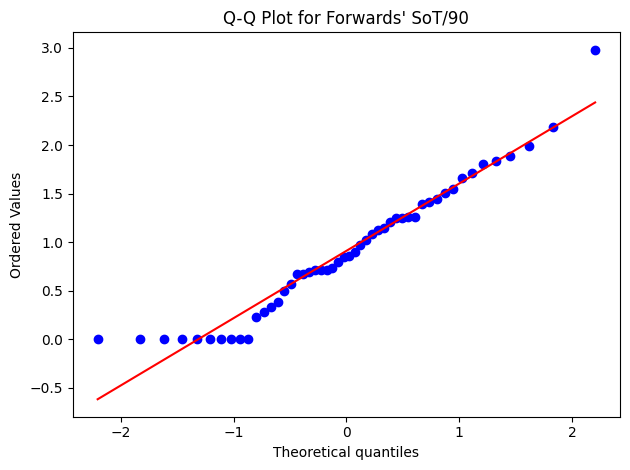

In [14]:
stats.probplot(
    forward_sot90,
    dist="norm",
    plot=plt
)

plt.title(
    "Q-Q Plot for Forwards' SoT/90"
)

plt.tight_layout()
plt.show()

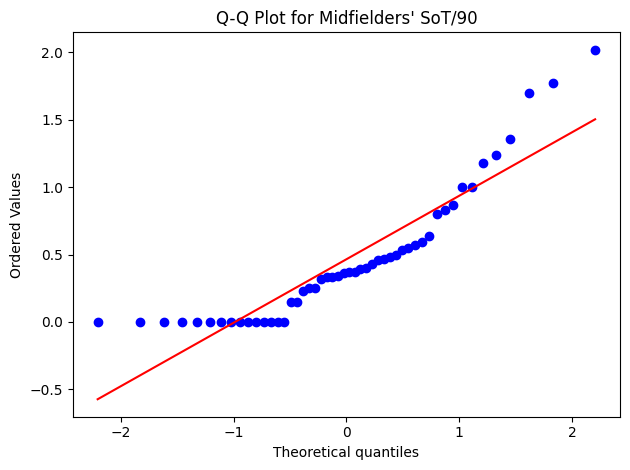

In [15]:
stats.probplot(
    midfielder_sot90,
    dist="norm",
    plot=plt
)

plt.title(
    "Q-Q Plot for Midfielders' SoT/90"
)

plt.tight_layout()
plt.show()

In [16]:
t_statistic, p_value = stats.ttest_ind(
    forward_sot90,
    midfielder_sot90,
    equal_var=False
)

print(
    "t-statistic:",
    round(
        t_statistic,
        4
    )
)

print(
    "p-value:",
    round(
        p_value,
        4
    )
)

t-statistic: 3.6872
p-value: 0.0004


In [17]:
alpha = 0.05

if p_value < alpha:

    print(
        "Reject the null hypothesis."
    )

    print(
        "There is statistically significant evidence "
        "of a difference in mean shots on target per 90 "
        "between forwards and midfielders."
    )

else:

    print(
        "Fail to reject the null hypothesis."
    )

    print(
        "There is insufficient statistical evidence "
        "of a difference in mean shots on target per 90 "
        "between forwards and midfielders."
    )

Reject the null hypothesis.
There is statistically significant evidence of a difference in mean shots on target per 90 between forwards and midfielders.


In [18]:
mean_difference = (
    forward_sot90.mean()
    -
    midfielder_sot90.mean()
)

se_difference = np.sqrt(
    forward_sot90.var(ddof=1)
    / len(forward_sot90)
    +
    midfielder_sot90.var(ddof=1)
    / len(midfielder_sot90)
)

numerator = (
    forward_sot90.var(ddof=1)
    / len(forward_sot90)
    +
    midfielder_sot90.var(ddof=1)
    / len(midfielder_sot90)
) ** 2

denominator = (
    (
        forward_sot90.var(ddof=1)
        / len(forward_sot90)
    ) ** 2
    / (
        len(forward_sot90) - 1
    )
    +
    (
        midfielder_sot90.var(ddof=1)
        / len(midfielder_sot90)
    ) ** 2
    / (
        len(midfielder_sot90) - 1
    )
)

welch_df = (
    numerator
    / denominator
)

t_critical = stats.t.ppf(
    0.975,
    df=welch_df
)

lower_difference = (
    mean_difference
    -
    t_critical
    * se_difference
)

upper_difference = (
    mean_difference
    +
    t_critical
    * se_difference
)

print(
    "Mean difference:",
    round(
        mean_difference,
        2
    )
)

print(
    "95% CI for mean difference:",
    round(
        lower_difference,
        2
    ),
    "to",
    round(
        upper_difference,
        2
    )
)

Mean difference: 0.45
95% CI for mean difference: 0.21 to 0.69


In [19]:
n1 = len(forward_sot90)
n2 = len(midfielder_sot90)

sd1 = forward_sot90.std(ddof=1)
sd2 = midfielder_sot90.std(ddof=1)

pooled_sd = np.sqrt(
    (
        (n1 - 1) * sd1**2
        +
        (n2 - 1) * sd2**2
    )
    /
    (n1 + n2 - 2)
)

cohens_d = (
    forward_sot90.mean()
    -
    midfielder_sot90.mean()
) / pooled_sd

print(
    "Cohen's d:",
    round(cohens_d, 2)
)

Cohen's d: 0.74
